***
<a id='beginning'></a> <!--\label{beginning}-->
* [总目录](../0_Introduction/0_introduction.ipynb)
* [术语表](../0_Introduction/1_glossary.ipynb)
* [4. 可见度空间](4_0_introduction.ipynb)
    * 上一节： [4.3 二元干涉仪](4_3_the_2-element_interferometer.ipynb)
    * 下一节： [4.5.1 UV 覆盖：UV 轨迹](4_5_1_uv_coverage_uv_tracks.ipynb)

***


导入标准模块:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
try:
    from IPython.display import HTML
except ImportError:
    def HTML(*args, **kwargs):
        return None
%matplotlib inline
HTML('../style/course.css')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12


导入本节所需的专用模块:

In [2]:
HTML('../style/code_toggle.html')


***

## 4.4 可见度函数


到目前为止，我们讨论的都是单次测量得到的单个可见度。随着干涉仪上方天空缓慢而连续地转动，投影基线也会随之缓慢连续变化，因此我们会测得一系列可见度采样，它们对应于某个连续可见度函数 $\mathcal{V}$ 的一组样本。在一定条件下，这个可见度函数与天空亮度分布的傅里叶变换直接相关。


基于[$\S$ 4.3 &#10142;](4_3_the_2-element_interferometer.ipynb)中的定义，我们现在来研究可见度函数，也就是干涉仪“看到”的天空。可见度函数与条纹模式的对比度有关，而条纹模式正是由每条基线两端天线接收到的信号组合而成的。


### 4.4.1 复可见度的数学定义


#### 4.4.1.1 比强度与表面亮度


[$\S$ 1.2 &#10142;](../1_Radio_Science/1_2_electromagnetic_radiation_and_astronomical_quantities.ipynb)已经介绍过，比强度 $I_{\nu}$（也称表面亮度）定义为单位立体角、单位频率间隔、单位接收面积所接收到的功率：
$$ dP_{\nu} = I_{\nu} d\Omega d\nu d A_{\text{eff}} $$

$dP_{\nu}$ 的单位为瓦特（W），而 $I_{\nu}$ 的单位为 W m$^{-2}$ sr$^{-1}$ Hz$^{-1}$。

写成积分形式后，面积 $A$ 在带宽 $\Delta \nu$ 上接收到一个通量密度为 $S$ 的源所贡献的总功率 $P_{\text{rec}}$ 为：
$$P_{\text{rec}}=\frac{1}{2} A S \Delta \nu$$


在相位中心 $\mathbf{s_0}$ 附近、方向偏移为 $\boldsymbol{\sigma}$ 的一小块天空区域，用立体角 $d\Omega$ 表示，则它在带宽 $\Delta \nu$ 上向接收面积 $A_{\text{eff}}$ 贡献的功率为：

$$dP(\boldsymbol{\sigma})= \frac{1}{2} A_{\text{eff}}(\boldsymbol{\sigma})I_\nu(\boldsymbol{\sigma})\Delta\nu d\Omega$$


<img src='figures/brightness.svg' width=40%>

<div class=advice>
<b>回顾定义：</b><br>

- 通量密度：$S_{\nu} = \int I_{\nu} d\Omega$，单位为 Jansky（Jy）<br>
- 通量：$F=\int_{\Delta \nu} \int_\Omega I_\nu d \Omega d\nu$，单位为 W m$^{-2}$<br>
- 接收功率：$P= \int_{A_\text{eff}}\int_{\nu} \int_\Omega I_\nu d \Omega d\nu d A_{\text{eff}}$，单位为 W<br>
其中 $\Omega$ 是源张成的立体角，单位为球面度（sr）。
</div>


<div class=warn>
<b>警告：</b> 信号在真空传播过程中，比强度 $I_{\nu}$ 保持不变，因此与源的距离无关；但通量密度 $S_{\nu}$ 会随距离按 $r^{-2}$ 衰减。
</div>


<div class=warn>
<b>警告：</b> 系数 $\frac{1}{2}$ 反映了大多数天线馈源具有偏振选择性（线偏振或圆偏振），因此面对非偏振源时通常只能接收到其中一半的功率。如果源的偏振方向与天线完全匹配，则天线可以测到全部功率。
</div>


上一节已经说明，干涉仪测得的是视场立体角 $\Omega$ 内不同天空区域贡献的总和。比强度 $I_\nu$ 在测量时既会被空间滤波器调制，这个滤波器取决于投影基线，也会被天线响应调制（这里先假定所有接收机完全相同），从而共同构成复可见度：

$$\boxed{\boxed{\mathcal{ V_{\mathbf{b}} } = \int_{\Omega} A_\text{eff}(\boldsymbol{\sigma})I_\nu(\boldsymbol{\sigma}) e^{-\imath 2\pi \frac{\textbf{b}\cdot \boldsymbol{\sigma}}{\lambda}} d\Omega}}$$

后面我们将使用对有效面积归一化后的可见度表达式，因此最后的单位与通量密度相同，均为 Jansky（Jy）。


<a id="vis:eq:441"></a> <!---\label{vis:eq:441}--->

$$\boxed{\boxed{\mathcal{ V_{\mathbf{b}} } = \int_{\Omega}I_\nu(\boldsymbol{\sigma}) e^{-\imath 2\pi \frac{\textbf{b}\cdot \boldsymbol{\sigma}}{\lambda}} d\Omega}} \text{ 单位 Jy}$$

**公式 4.4.1**


#### 4.4.1.2 条纹模式的表示


在[$\S$ 4.2 &#10142;](../4_Visibility_Space/4_2_the_baseline_and_its_representation_in_space.ipynb)中，我们已经用多种坐标系表示过天空参考系中的基线。现在用这些坐标来把可见度 $\mathcal{V}_{\mathbf{b}}$ 写成显式形式。

$\boldsymbol{\sigma}$ 是方向差矢量，定义为 $\boldsymbol{\sigma}= \mathbf{s} - \mathbf{s_0}$。

在 $(u,v,w)$ 坐标系中，$\mathbf{s_0}$ 的方向就是 $w$ 轴方向。因此：

$$
\begin{aligned}
\mathbf{s_0}&=&
\begin{pmatrix}
0 \\
0 \\
1 \\
\end{pmatrix}
\end{aligned}
$$

$$
\begin{aligned}
\mathbf{s}
&=&
\begin{pmatrix}
l \\
m \\
n \\
\end{pmatrix}
\end{aligned}
$$

$$
\begin{aligned}
\mathbf{b}_{\lambda}
&=&
\mathbf{ \frac{\mathbf{b}}{\lambda}}
=
\begin{pmatrix}
u \\
v \\
w \\
\end{pmatrix}
\end{aligned}
$$


点积 $\mathbf{b} \cdot \boldsymbol{\sigma}$ 可以写成 $(u,v,w)$ 与 $(l,m,n)$ 的函数：



$$ \mathbf{b_\lambda} \cdot \boldsymbol{\sigma}= ul + vm + (n-1)w $$

根据 [Eq. 4.4.1 &#10549;](#vis:eq:441)，我们还需要把立体角元素 $d\Omega$ 写成 $(l,m,n)$ 的形式。由于
$d \Omega = d\theta \sin \theta d\phi$，
因此也可以利用方向余弦坐标表示天球上的面积元素。通过 Jacobian 行列式可得：

$$d \Omega = \frac{dl dm}{n} = \frac{dl dm}{\sqrt{1 - l^2 - m^2}}$$


<a id="vis:eq:442"></a> <!---\label{vis:eq:442}--->

$$\boxed{\boxed{\mathcal{ V }(u,v,w) = \int_{-\infty}^{\infty}\int_{-\infty}^{\infty} A(l,m)I_\nu(l,m) \exp \left[ {-\imath 2\pi (ul+vm+w(\sqrt{1-l^2-m^2}-1)) }\right] \frac{dl dm}{\sqrt{1 - l^2 - m^2}}}}$$

**公式 4.4.2**


<div class=warn>
<b>注意：</b> 积分上下限可以形式上取为无穷大，但被积函数本身是有界的，因为当 $l^2+m^2 \geq 1$ 时，$A$ 和 $I_\nu$ 都为零。
</div>


如果满足以下条件：
- 视场 $\Omega$ 很小
- 波束 $A(l,m)$ 非常集中，也就是很快衰减到零
- 源都靠近相位中心 $(l=0,m=0)$
- $w$ 项很小

也就是 $l,m \ll 1$，则有

$w(\sqrt{1-l^2-m^2}-1) \sim -\frac{1}{2}(l^2+m^2)w$

于是 [Eq. 4.4.2 &#10549;](#vis:eq:442) 可以近似写为：

<a id="vis:eq:443"></a> <!---\label{vis:eq:443}--->

$$ \mathcal{V}(u,v,w \sim 0) = \int_{-\infty}^{\infty} \int_{-\infty}^{\infty} \frac{A(l,m) I_\nu (l,m)}{\sqrt{1 - l^2 - m^2}}  e^{ -\imath 2\pi (ul+vm)}dl dm$$


**公式 4.4.3**


#### 4.4.1.3 与傅里叶变换的关系


公式 [Eq. 4.4.3 &#10549;](#vis:eq:443) 中已经不再含有 $w$ 项，因此它呈现出 $(u,v)$ 与 $(l,m)$ 之间二维傅里叶变换的形式（见[$\S$ 2.4 &#10142;](../2_Mathematical_Groundwork/2_4_the_fourier_transform.ipynb)）。其逆变换为：

$$ \frac{A(l,m) I_\nu(l,m)}{\sqrt{1 - l^2 - m^2}} = \int_{-\infty}^{\infty} \int_{-\infty}^{\infty} \mathcal{V}(u,v) e^{ +\imath 2\pi (ul+vm)}du dv$$

$$ \mathcal{V}(u,v) \sim \mathscr{F} \{I_\nu \}(u,v) $$

在[$\S$ 4.6 &#10142;](../4_Visibility_Space/4_6_the_fourier_approximation_van_cittert-zernike_Theorem.ipynb)中，我们会进一步看到这种写法的意义。


<a id="vis:sec:442"></a> <!---\label{vis:sec:442}--->
### 4.4.2 理解可见度函数


#### 4.4.2.1 可见度函数的表示


$I_\nu$ 与 $\mathcal{V}$ 之间的傅里叶关系至关重要，因为干涉仪真正采样到的是后者，也就是 $\mathcal{V}$。换句话说，干涉仪并不是直接对“天空本身”敏感，而是对“天空的傅里叶变换”敏感。为了从 $\mathcal{V}$ 中恢复天空的信息，我们必须先理解可见度函数本身，把它视为一个连续的复函数。

$\mathcal{V}$ 是傅里叶空间中的一个二维函数。在某一时刻 $t$、某一频率 $\nu$ 下，一条基线和一个指向方向 $\mathbf{s_0}$ 会唯一确定傅里叶空间中的一个 $(u,v)$ 点，这个点就对应复可见度函数的一次采样。

在干涉测量的早期，可用采样点很少，直接在二维平面中观察这些采样并不现实，因此常常研究可见度幅度与“uv 距离” $r_{uv}$ 的关系，其中

$$ r_{uv} = \sqrt{u^2+v^2}$$

下面我们先不利用可见度与亮度分布之间完整的傅里叶关系，而是通过一个简单例子做数值积分演示。傅里叶变换在成像中的作用会在[$\S$ 5.1 &#10142;](../5_Imaging/5_1_spatial_frequencies.ipynb)中进一步讨论。


#### 4.4.2.2 将积分理解为空间滤波


可见度可以写成亮度分布与复指数核函数乘积的积分，这个复指数通常称为“傅里叶核”。

如果把亮度分布看作一个按方向排列的向量，那么上式就可以理解为亮度分布向量 $\mathbf{I_\nu}$ 与傅里叶基函数 $\mathbf{f}_{u,v}^{l,m}$ 的标量积，其中 $\mathbf{f}_{u,v}^{l,m}= e^{-2j\pi (ul+vm)}$：

$$ \mathcal{V}= \langle \mathbf{I_\nu} \cdot \mathbf{f}_{u,v}^{l,m}\rangle$$

这可以视为 $\mathbf{I_\nu}$ 在基向量 $\mathbf{f}_{u,v}^{l,m}$ 上的投影。因此，对于位于 $(u,v)$ 的一条基线而言，其复可见度就是亮度分布在该空间频率傅里叶基向量上的系数。换句话说，这个运算提取了亮度分布中位于空间频率 $(u,v)$ 的分量。

傅里叶基向量还可以理解为投影到天空上的条纹模式（见 [Fig. 4.4.1 &#10549;](#vis:fig:441)），干涉仪就是通过这样的条纹模式来“读取”天空中的结构信息。


<a id="vis:fig:441"></a> <!---\label{vis:fig:441}--->
<img src='figures/uvfreq.svg' width=30%>

**图 4.4.1**：位于 $(u,v)$ 的单个空间频率及其对应的天空条纹模式。


对于一个观测近似平面天空的二元干涉仪，我们可以在 $(u,v,w)$ 参考系中建立“物理”基线 $\mathbf{b}$ 与“投影”基线 $\mathbf{b_\text{proj}}$ 的联系，并在 $(l,m,n)$ 参考系中建立相位中心 $\mathbf{s_0}$ 与观测方向 $\mathbf{\sigma}$ 的联系，如图 [Fig. 4.4.2 &#10549;](#fvis:fig:442) 所示。


<a id="vis:fig:442"></a> <!---\label{vis:fig:442}--->
<img src='figures/spatialfiltering.png' width=70%>

**图 4.4.2**：投影基线、$(u,v,w)$ 空间与 $(l,m,n)$ 空间之间的关系。


根据 [Eq. 4.4.3 &#10549;](#vis:eq:443)，对于一条坐标为 $(u,v,w)$ 的投影基线，其可见度函数 $\mathcal{V}(u,v,w)$ 的值，是视场 $dldm$ 内、来自方向 $\boldsymbol{\sigma}(l,m)$ 的全部强度贡献之和。如果这个视场中包含多个复杂结构的源，那么可见度函数会成为一个较复杂的 $(u,v,w)$ 函数，直观理解并不容易。


##### 4.4.2.3 可见度的应用：探测源的形状


考虑一个二元干涉仪，其投影基线为 $(u,v=0,w=0)$，于是会得到一组沿 $l$ 方向变化的条纹。这类情形可由一条东西向基线实现（见[$\S$  4.5.1 &#10142;](4_5_1_uv_coverage_uv_tracks.ipynb)）。

假定天空中只有一个扩展源，我们用一个单位亮度的圆盘来表示它。为简化讨论，假定观测发生在该源经过本地子午线、恰好位于相位中心的时候。

再假定这是干涉仪视场内唯一的源，因此可以忽略天线方向图的影响，并取 $w=0$。

于是 [Eq. 4.4.3 &#10549;](#vis:eq:443) 中的积分就简化为对源范围内条纹模式的积分：
$$ \mathcal{V} = \int_{\text{disk}} e^{-2j\pi ul}dl$$


In [3]:
# 1 East-West baseline observing a disk at the phase center
from matplotlib.patches import Circle
def plotfringe(u=4,rad=0.2):
    global radius
    radius=rad
    # preparing (l,m,n) space
    Npointsl=1001
    ll=np.linspace(-1.,1.,Npointsl)
    l,m=np.meshgrid(ll,ll)

    # Definition of the disk
    #radius=0.1234 # angular radius of the object in l,m coordinates

    # projected baseline length on the u axis
    #u=4

    # generate fringe pattern
    tabcos=np.real(np.exp(-2j*np.pi*u*l))

    # plotting the fringe pattern and the source
    pxrad=radius*Npointsl/2
    circle=Circle((500,500),pxrad,color='r',alpha=0.5,fill=True)
    fig,ax =plt.subplots(figsize=(6,6))
    im=plt.imshow(np.abs(tabcos),interpolation=None,cmap="winter")
    ax.add_patch(circle)
    #center=l[(Npoints-1)/2,(Npoints-1)/2]

    # Compute the absolute value of the integral of the fringe over the source
    w=np.where(np.sqrt(l**2+m**2) <= radius)
    integral=np.sum(tabcos[w])
    print("Integral="+str(integral))



Integral=12341.470568575238


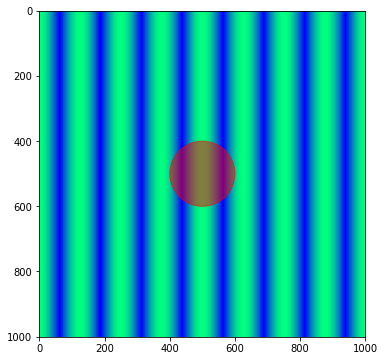

In [4]:
plotfringe(u=2,rad=0.2)

<a id="vis:fig:443"></a> <!---\label{vis:fig:443}--->
**图 4.4.3**：透过条纹模式观察天空中的扩展源（红色圆盘），对应的投影基线坐标为 $(u,0,0)$。


在图 [Fig. 4.4.3 &#10549;](#vis:fig:443) 中，叠加在条纹上的红色圆盘代表源。可以看到，亮条纹穿过源的面积并不与暗条纹完全平衡，因此积分结果为正。接下来让我们增大 $u$ 的值，也就是增加投影基线长度。


Integral=-2140.9617023213596


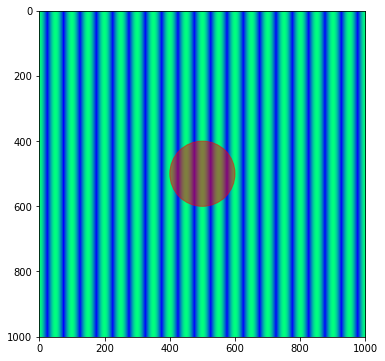

In [5]:
plotfringe(u=5,rad=0.2)

<a id="vis:fig:444"></a> <!---\label{vis:fig:444}--->
**图 4.4.4**：在更长的投影基线下，透过新的条纹模式观察同一个源。


由图 [Fig. 4.4.4 &#10549;](#fig:444) 可见，积分绝对值比之前大约小了 10 倍，这说明积分区域内亮条纹与暗条纹的贡献更加接近平衡；但由于积分结果仍为负，说明暗条纹仍略占优势。

由此可以推断，随着条纹宽度继续减小，积分结果最终会趋近于零，也就是说，穿过源的亮暗条纹贡献越来越接近相等。

下面我们重点考察：随着 $u$ 增大，积分结果的绝对值如何变化。


In [6]:
def plotintegral(UMAX=15):
    %matplotlib inline
    global u
    from matplotlib.patches import Circle

    #UMAX=5. # adjust it to larger values if no zeroes is encountered in next plot

    Npointsl=1001
    Npointsu=500
    ll=np.linspace(-1.,1.,Npointsl)
    l,m=np.meshgrid(ll,ll)
    u=np.arange(Npointsu)*UMAX*1./Npointsu
    w=np.where(np.sqrt(l**2+m**2) <= radius)
    
    integral=np.array([])
    for du in u:
        tabcos=np.real(np.exp(2j*np.pi*du*l))
        integral=np.append(integral,np.abs(np.sum(tabcos[w])))

    normintegral=integral/np.max(integral)
    plt.xlabel('Spatial frequency u')
    plt.ylabel('Normalized integral over source')
    plt.plot(u,normintegral,".-")
    return normintegral


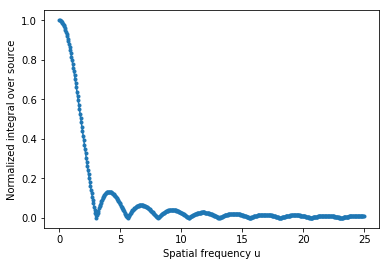

In [7]:
integral=plotintegral(UMAX=25.)

<a id="vis:fig:445"></a> <!---\label{vis:fig:445}--->
**图 4.4.5**：源上积分结果随空间频率 $u$ 变化的曲线。


从图 [Fig. 4.4.5 &#10549;](#vis:fig:445) 可见，当 $u$ 从 0 增加到 25 时，在若干特定位置（记作 $u_\text{min}^{(n)}$）积分结果接近于零。这意味着源在亮条纹上的积分与在暗条纹上的积分大致相等：

$$ \int_{\text{bright }\cap\text{ source}} e^{-2j\pi ul}dl \approx \int_{\text{dark }\cap\text{ source}} e^{-2j\pi ul}dl$$

当积分结果，也就是可见度函数，变为零时，对应着穿过源的条纹对比度为零。此时我们称源已经“被分辨开”（resolved）。第一次出现零点时对应的 $u$ 值，即 $u_\text{min}^{(1)}$，与所观测源的几何形状密切相关。

现在来估算 $u_\text{min}^{(1)}$ 的近似值。


In [8]:
def findumin(normintegral,ulim=5):############
    # Adjust ulim to search for the first minimum of the integral
    # 
    #ulim=5 # should be an value larger than the first minimum
    wloc=np.where(u <= ulim)
    ############

    locmin=np.where(normintegral[0:wloc[0][-1]] == np.min(normintegral[0:wloc[0][-1]]))
    print("Index first minimum = "+str(locmin[0][0]))
    print("Normalized integral value at first min = "+str(normintegral[locmin][0]))
    print("Spatial frequency at first min = "+str(u[locmin][0]))

    umin=u[locmin][0]

    deltal=1.22/(2*umin) # Bessel function :  J1(3.83)=0=J1(2*pi*f*r)
    print
    print("Spatial scale at first min = "+str(deltal))
    print("True object radius = "+str(radius))

In [9]:
findumin(integral,ulim=5)

Index first minimum = 61
Normalized integral value at first min = 0.0005542885165989534
Spatial frequency at first min = 3.05
Spatial scale at first min = 0.2
True object radius = 0.2


在这个计算例子中，我们得到 $u_\text{min}^{1}=3.05$。由于观测目标是圆盘，它的可见度函数可以用一阶贝塞尔函数 $\mathcal{J}_1$ 描述。我们知道
$\mathcal{J}_1(2\pi u_\text{min}^{1} l)=\mathcal{J}_1(3.8317) \approx 0$，
因此第一个零点满足：

$$
\begin{aligned}
2 \pi u l &\approx& 3.8317 \\
l&\approx&\frac{1.22}{2 u_\text{min}^{1}} \\
l&\approx&0.2
\end{aligned}
$$

推得 $l=0.2$，而本例中源的“真实”半径也恰好是 0.2，结果非常吻合。


在这个简单例子中，我们测得了目标的半径。如果系统性能足够好、基线相对于波长足够长，那么即使不做成像，也可以测量远处恒星的角半径。

这个例子说明，干涉仪可以通过信号合成技术，把多个低角分辨率仪器组合起来，从而分辨非常遥远的目标。

详细内容可参考 [<cite data-cite='1966raas.book.....K'>Kraus, $\S$6-27</cite> &#10548;](http://adsabs.harvard.edu/abs/1966raas.book.....K) 和 [<cite data-cite='1999ASPC..180.....T'>Taylor, $\S$ 16, p.338</cite> &#10548;](http://adsabs.harvard.edu/abs/1999ASPC..180.....T)。

下面我们继续看，如何利用可见度来确定源的位置。


#### 代码演示：源大小写进幅度包络，源位置写进相位斜率

前一个圆盘例子已经说明，可见度幅度会随着基线增大而衰减，因此可以用来测量源的尺度。这里再往前走一步，把“源形状”和“源位置”这两件事分开来看。我们构造三个一维高斯源：一个窄而位于相位中心，一个宽而位于相位中心，以及一个与第二个形状完全相同、但整体偏离相位中心的源。

这三个模型恰好对应可见度分析里最常见的两条经验。第一，源越宽，傅里叶域中的幅度包络越窄；第二，若只把源整体平移而不改变形状，则幅度基本不变，但相位会出现线性斜坡。后者正是“源位置写进相位”的最基本原型。


In [ ]:
l = np.linspace(-0.5, 0.5, 1501)
dl = l[1] - l[0]
u = np.linspace(-15.0, 15.0, 601)


def gaussian_sky(l_coords, sigma, center=0.0):
    profile = np.exp(-0.5 * ((l_coords - center) / sigma) ** 2)
    profile /= np.trapezoid(profile, l_coords)
    return profile


def visibility_1d(u_coords, l_coords, brightness):
    phase = np.exp(-2j * np.pi * np.outer(u_coords, l_coords))
    return dl * phase @ brightness


sky_narrow = gaussian_sky(l, sigma=0.035, center=0.0)
sky_broad = gaussian_sky(l, sigma=0.10, center=0.0)
sky_shifted = gaussian_sky(l, sigma=0.10, center=0.12)

V_narrow = visibility_1d(u, l, sky_narrow)
V_broad = visibility_1d(u, l, sky_broad)
V_shifted = visibility_1d(u, l, sky_shifted)

amp_difference = np.max(np.abs(np.abs(V_broad) - np.abs(V_shifted)))
mask = np.abs(V_shifted) > 1e-3 * np.max(np.abs(V_shifted))
phase_slope = np.polyfit(u[mask], np.unwrap(np.angle(V_shifted[mask])), 1)[0]
print(f'Max amplitude difference between centered and shifted broad source = {amp_difference:.3e}')
print(f'Fitted phase slope for the shifted source = {phase_slope:.3f} rad per unit u')

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

axes[0].plot(l, sky_narrow, lw=2, label='narrow centered Gaussian')
axes[0].plot(l, sky_broad, lw=2, label='broad centered Gaussian')
axes[0].plot(l, sky_shifted, lw=2, ls='--', label='broad shifted Gaussian')
axes[0].set_xlabel('Direction cosine l')
axes[0].set_ylabel('Normalized brightness')
axes[0].set_title('Three source models in the sky domain')
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

axes[1].plot(u, np.abs(V_narrow), lw=2, label='narrow centered Gaussian')
axes[1].plot(u, np.abs(V_broad), lw=2, label='broad centered Gaussian')
axes[1].plot(u, np.abs(V_shifted), lw=2, ls='--', label='broad shifted Gaussian')
axes[1].set_xlabel('Spatial frequency u')
axes[1].set_ylabel(r'$|V(u)|$')
axes[1].set_title('Source size controls the amplitude envelope')
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)

phase_mask = np.abs(V_broad) > 1e-3 * np.max(np.abs(V_broad))
axes[2].plot(u[phase_mask], np.unwrap(np.angle(V_broad[phase_mask])), lw=2, label='broad centered Gaussian')
axes[2].plot(u[mask], np.unwrap(np.angle(V_shifted[mask])), lw=2, ls='--', label='same source, shifted')
axes[2].set_xlabel('Spatial frequency u')
axes[2].set_ylabel('Unwrapped phase [rad]')
axes[2].set_title('Source position controls the phase slope')
axes[2].grid(alpha=0.3)
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()


这组图把可见度里最核心的两类信息拆开了。源越宽，幅度包络衰减得越快，因此长基线会更早把它“分辨开”；而把同一个源整体平移到相位中心之外时，幅度几乎不变，但相位会随 $u$ 呈近似线性变化。

这两条规律在后面会不断出现。测量源大小时，我们主要盯着幅度如何随基线变化；做相位跟踪、定位源位置或理解相位中心偏移时，则主要看相位斜率。也正因为二者承担的信息不同，复可见度的实部和虚部、幅度和相位，缺一不可。


##### 4.4.2.4 可见度的应用：定位源的位置 <a id="vis:sec:4424"></a> <!--\label{vis:sec:4424}--></a>


##### 4.4.2.4.1 未知赤经/赤纬的中天源


为了减弱带宽效应对条纹的影响，干涉仪通常会对延迟 $\tau$ 做补偿，也就是插入一个额外延迟 $\tau_c$，使条纹模式的相位中心与观测相位中心对齐。如果我们完全不做相位跟踪，而是让相位中心始终指向天顶，会发生什么？这就得到一个子午干涉仪。

在这个例子里，我们假定天空中只有一个赤经、赤纬未知的点源，并希望利用干涉仪对它进行精确定位。同时还假定天线视场足够大，以至于在整个观测期间波束变化很平缓。把天线指向本地子午线（$H=0^\text{h}$）后，子午干涉仪会在天空上投影出一组条纹模式。当源穿过视场时，条纹会受到天线波束的调制。

当天球上的源穿过干涉仪投影到天空中的条纹模式时，干涉仪响应会随地方恒星时 LST 发生变化（[Fig. 4.4.6 &#10549;](#vis:fig:446) 中绿色曲线）。


<a id="vis:fig:446"></a> <!---\label{vis:fig:446}--->
<img src='figures/fringes.svg' width=50%>

**图 4.4.6**：条纹率与中天时间的推导示意图。


##### 4.4.2.4.2 估算赤经 $\alpha$

如果能够精确测量源通过本地子午线的时刻，就能确定该源的赤经。因为天线始终指向本地子午线，所以当源穿过本地子午线时，天线响应达到最大；根据[$\S$ 3.2 &#10142;](../3_Positional_Astronomy/3_2_Hour_Angle.ipynb)，此时的地方恒星时就等于该源的赤经。本例中，源的赤经约为 $13^\text{h}07^\text{m}$。


##### 4.4.2.4.3 估算赤纬 $\delta$

根据条纹间距和条纹率，可以估算出源的赤纬。

- 定义条纹间距 $\Delta l_f$，即投影到天空中的条纹模式里一个条纹周期所对应的角距离。这个间距可由 $\Delta l_f \sim \frac{\lambda}{|\mathbf{b}|}$ 估算。本例中，$\Delta l_f \sim \frac{1}{2864}\,\text{rad}=0.02\text{ rad}\approx1.14^\circ$。
- 定义条纹率 $\frac{d\phi}{d\theta}$，它描述源穿过条纹模式时条纹振荡的快慢。接下来我们要估算源穿过一个条纹周期所需的时间。

从图 [Fig. 4.4.6 &#10549;](#vis:fig:446) 中可估计，条纹间隔约为 12 分钟，也就是在 1 小时的观测中，源大约穿过 5 个条纹周期。

对于位于天赤道上的源（$\delta =0^\circ$），它每小时移动 15$^\circ$。这个角位移对应若干个条纹周期，因此只要数出每小时穿过的条纹数，就能反推出源的位置信息。

既然条纹间距已知，就能得到赤道上的条纹率
$\frac{d\phi}{d\theta}\Bigr|_\text{eq}=\frac{\Delta l_f}{15^\circ \text{per h}} \approx 0.77 h \approx 4^\text{m}33^\text{s}$。

相反，靠近北天极的源（$\delta \sim 90^\circ$）会表现出很小的条纹间距和条纹率。

把图 [4.4.6 &#10549;](#fig:436) 中测得的条纹率与赤道上的条纹率比较，就可以估算出源的赤纬：

$$\cos \delta= \frac{d\phi}{d\theta}\Bigr|_\text{eq} /  \frac{d\phi}{d\theta}\Bigr|_\text{mes}=\frac{4^\text{m}33^\text{s}}{12^\text{m}}=0.3825 \leftrightarrow \delta \approx 67.7^\circ$$


#### 4.4.2.5 条纹率映射


“条纹率映射”技术（见 [<cite data-cite='1996ASPC..101..175K'>Kogan, 1996</cite> &#10548;](http://adsabs.harvard.edu/full/1996ASPC..101..175K) 和 [<cite data-cite='1996ASPC..101..175K'>Walker, 1981</cite> &#10548;](http://adsabs.harvard.edu/full/1981AJ.....86.1323W)）利用的是源相对于相位中心所引起的条纹率偏移信息。

在二维参考系中，条纹率偏移定义为：

<a id="vis:eq:444"></a> <!---\label{vis:eq:444}--->

$$ \omega_{\text{frm}}= 2\pi (\frac{du}{dt}l+\frac{dv}{dt}m)$$

其中，$(u,v)$ 是投影基线坐标，$(l,m)$ 是相对于相位中心的方向余弦坐标。


设 $m=f(l)$，则 [Eq. 4.4.4 &#10549;](#vis:eq:444) 可以写成线性函数 $y=ax+b$ 的形式。

每条基线都会在天空上产生一组条纹，这些条纹的间距和方向因基线而异。由于从源的角度看，基线会随时间旋转，因此条纹也会在天空上旋转。每个源都会按自己距离相位中心的远近，以不同条纹率调制可见度；离相位中心更远的源会贡献更快的条纹率变化。

##### 4.4.2.5.1 单源

如果天空中只有一个位置未知的源，那么可见度幅度会在某个特定条纹率上表现出周期性变化（见前面的例子）。

如果我们能够测出这种随时间变化的周期性，也就是测得 $\frac{du}{dt}$ 和 $\frac{dv}{dt}$，就可以画出一条直线 $m=f(l)$，表示天空中所有可能产生这一条纹率的位置。

如果再加入第二条基线，就会得到另一组可见度随时间变化的关系，也就是另一组 $\left(\frac{du}{dt},\frac{dv}{dt}\right)$ 参数，从而得到另一条直线。

两条直线的交点，就给出了产生这组可见度变化的源在天空中的位置。

##### 4.4.2.5.2 多源

如果天空中有多个亮源，就必须研究可见度随时间变化的频谱，并寻找其中的多个峰值，每个峰值都对应一组 $\frac{du}{dt}$ 和 $\frac{dv}{dt}$。对每条基线的时间序列做 FFT 后，就能为每个峰值得到一条直线。

最终，这些直线方程会在 $(l,m)$ 平面上产生多个交点，它们对应于视场中的主要源。值得注意的是，这里完全没有进行成像，我们仍然能推断出源的位置。


<div class=warn>
<b>警告：</b> 许多工作也可以只利用可见度的相位来完成。这正是高精度天体测量，尤其是 VLBI 天体测量中的核心研究方向之一。感兴趣的读者可参考 [<cite data-cite='2001isra.book.....T'>Thompson, Moran and Swenson, $\S$12, p.467</cite> &#10548;](http://adsabs.harvard.edu/abs/2001isra.book.....T)。
</div>


### 4.4.3 小结


本节介绍了可见度函数的主要性质。接下来我们将讨论可见度函数的采样问题，重点关注测得的 $(u,v,w)$ 频率如何随着仪器参数和观测参数而变化。


我们已经说明了如何在三维参考系中描述一条基线，下一步则是讨论如何把这条基线投影到二维平面上。可以想象自己站在天球上，向下俯视基线分布，那么这些基线就会投影到一个二维平面上。

本章后面的[$\S$ 4.6 &#10142;](4_6_the_fourier_approximation_van_cittert_zernike_theorem.ipynb)将讨论如何通过一个近似的二维傅里叶变换，把基线对可见度的采样恢复为天空图像。这个定理有不少重要的限制条件，我们会在后文合适的地方详细说明。

此处最重要的结论是：对于天球上的某一个方向，对应的三维基线可以投影到二维平面，而随着地球自转（天球相对保持固定），每条基线的投影都会发生变化。这种投影变化正是射电干涉测量得以实现的重要基础，我们会在[$\S$ 4.5.1 &#10142;](4_5_1_uv_coverage_uv_tracks.ipynb)中再次回到这个问题。


<p class=conclusion>
  <font size=4><b>记忆要点</b></font>
  <br>
  
&bull; 在简化假设下，可见度函数与亮度分布之间满足 <b>二维傅里叶变换</b> 关系。<br>
&bull; 对 $(u,v)$ 处的可见度积分，本质上返回的是该 $(u,v)$ 空间频率对应的 <b>系数</b>。<br>
&bull; 通过分析这个积分的性质，即使不成像，也能推导出源的大小和位置。<br>
</p>


***

* 下一节： [4.5.1 UV 覆盖：UV 轨迹](4_5_1_uv_coverage_uv_tracks.ipynb)
